# Machine Learning Basics: praktijkdeel

Deze notebook bevat het praktijkdeel van het examen Machine Learning Basics. Volg de onderstaande instructies om de opdracht uit te voeren.
Je hebt de resterende tijd van de 3 uur voor het examen om deze opdracht te voltooien. De vragen in deze opdracht staan geformuleerd binnen de notebook in het Engels, maar je mag in het Nederlands antwoorden. Je dient de vraag te beantwoorden met code en/of tekst en/of visualisaties, afhankelijk van wat er gevraagd wordt.
De indiening gebeurt via de cloudtoepassing. Je dient zowel deze notebook als een HTML-export van deze notebook in te dienen. Zorg ervoor dat je naam en studentnummer duidelijk zichtbaar zijn in beide bestanden en dat de output van alle codecellen zichtbaar is in de HTML-export.

Succes!

## Fizzy Business: How Machine Learning Helps Predict Soda Types

Understanding the chemical composition of beverages is crucial for quality control and product development in the beverage industry. Measuring properties such as sugar content, caffeine level, acidity, and carbonation helps manufacturers ensure consistent taste and quality. However, comprehensive testing of all properties can be time-consuming and costly, making it valuable to predict certain characteristics from others.

Beverage companies are constantly working to optimize their formulations and understand the relationships between different chemical properties. One important aspect is understanding how various measurable properties relate to each other, which can help in quality control and new product development.

A major beverage company reached out to you as a machine learning expert for assistance in understanding their soda properties. They've provided you with a dataset called `soda_properties.csv`, which contains various chemical and physical measurements of different soda samples.

The dataset includes multiple numeric features representing different properties of the soda samples:
- **sugar_content**: Sugar content level (0-100 scale)
- **caffeine_content**: Caffeine content level (0-60 mg per 100ml)
- **acidity_level**: Acidity level (35-45 scale)
- **carbonation_level**: Carbonation level (5.0-8.0 scale)
- **soda_type**: Type of soda drink (target variable)

In this project, you will explore the dataset and build a machine learning model to predict the type of soda based on its chemical properties to investigate the relationships between the properties and the soda types.

In [ ]:
import pandas as pd

# Load the dataset
sodas = pd.read_csv("../data/soda_properties.csv")

sodas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sugar_content      2200 non-null   int64  
 1   caffeine_content   2200 non-null   int64  
 2   acidity_level      2200 non-null   int64  
 3   carbonation_level  2200 non-null   float64
 4   soda_type          2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [ ]:
#####################
# VRAAG 1: Exploreer de dataset. Welke kolommen bevatten mogelijk nuttige informatie om het type soda te voorspellen? 
# Welke kolommen lijken minder relevant? Leg uit waarom
#####################


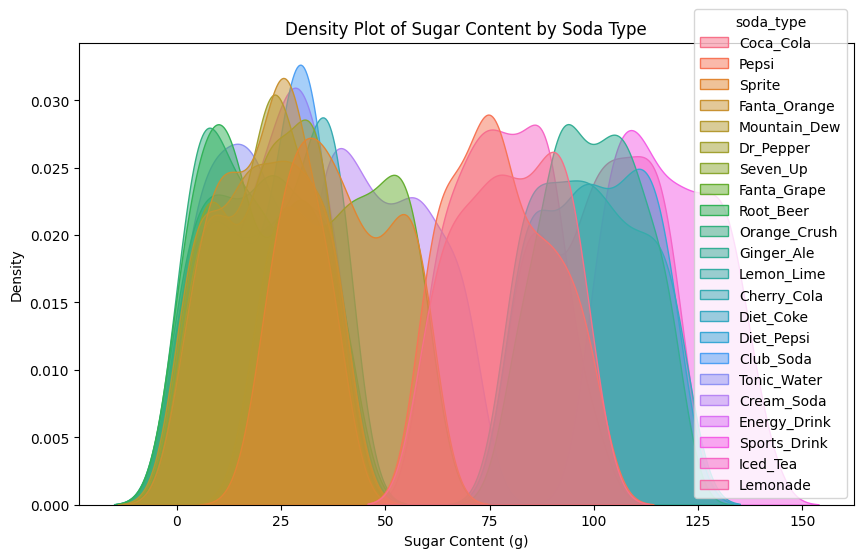

In [ ]:
# Create histograms for each variable by soda type
import matplotlib.pyplot as plt
import seaborn as sns

# Density plot of sugar content by soda type
# plt.figure(figsize=(10, 6))
# sns.kdeplot(data=sodas, x="sugar_content", hue="soda_type", fill=True, common_norm=False, alpha=0.5)
# plt.title("Density Plot of Sugar Content by Soda Type")
# plt.xlabel("Sugar Content (g)")
# plt.ylabel("Density")
# plt.show()
# Plot for each soda type the average and standard deviation of caffeine content in one plot
plt.figure(figsize=(10, 6))
sns.barplot(data=sodas, x="soda_type", y="caffeine_content", ci="sd", capsize=.2)
plt.title("Average Caffeine Content by Soda Type with Standard Deviation")
plt.xlabel("Soda Type")
plt.ylabel("Caffeine Content (mg)")
plt.show()



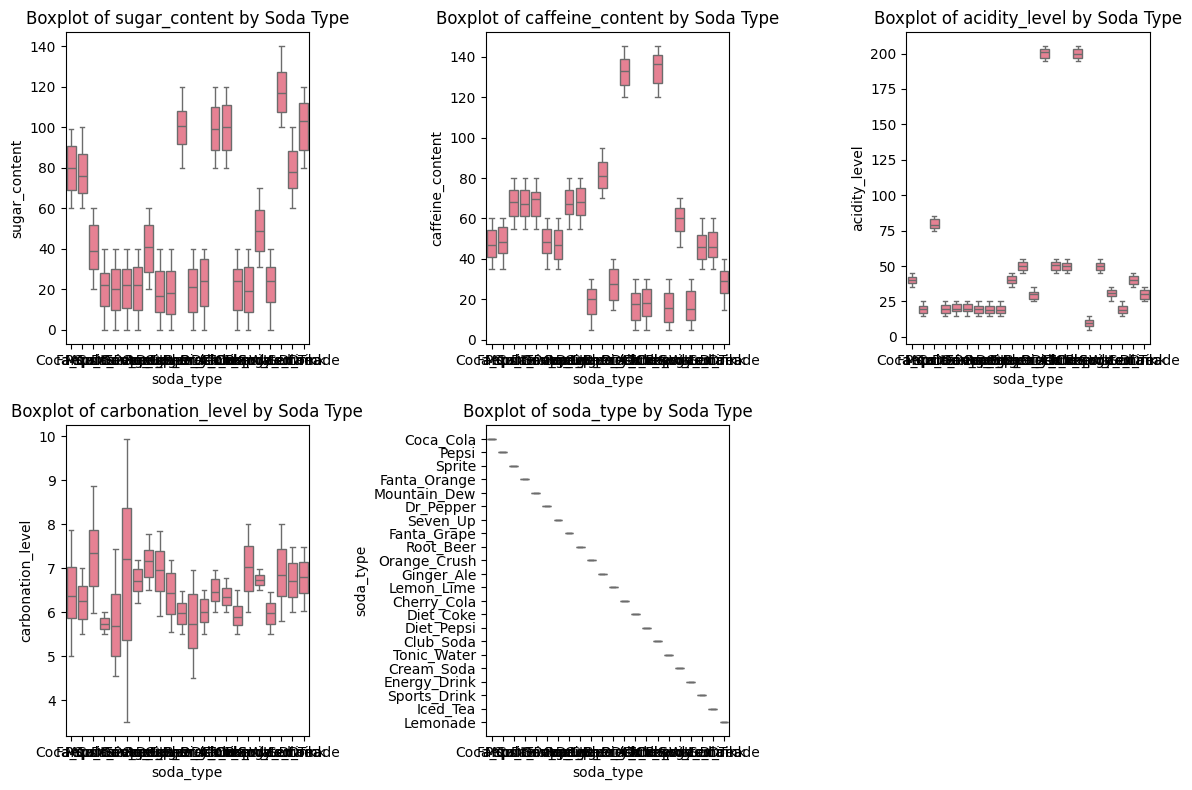

In [21]:
# Visualize each variable by soda type in boxplots
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for i, column in enumerate(sodas.columns[0:], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='soda_type', y=column, data=sodas)
    plt.title(f'Boxplot of {column} by Soda Type')
plt.tight_layout()
plt.show()

Om de predictieve sterkte van de verschillende eigenschappen te onderzoeken, maken we een model dat het type frisdrank voorspelt op basis van 1 enkele eigenschap. We herhalen dit voor alle eigenschappen en vergelijken de resultaten van de f1-score.

In [ ]:
# All required libraries are imported here for you.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics


# Check for missing values
sodas.isna().sum()

# Check how many soda types we have, i.e., multi-class target
sodas.soda_type.unique()

# Split into feature and target sets - VUL AAN
X = sodas.drop(columns="soda_type")
y = sodas["soda_type"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#######
# VRAAG: hieronder is F1 score berekend bij het gebruik van de variabele 'x'. 
# Wat zijn de f1 scores voor elk van de andere variabelen?
# Welke variabele heeft als single variable de hoogste f1 score?
######

# Create a dictionary to store the model performance for each feature
feature_performance = {}

# Train a logistic regression model for each feature
for feature in ["sugar_content", "caffeine_content", "acidity_level", "carbonation_level"]:
    log_reg = LogisticRegression(random_state=42) # multi_class="multinomial"
    log_reg.fit(X_train[[feature]], y_train) 
    y_pred = log_reg.predict(X_test[[feature]])
    
    # Calculate F1 score, the harmonic mean of precision and recall
    # Could also use balanced_accuracy_score
    f1 = metrics.f1_score(y_test, y_pred, average="weighted")
    
    # Add feature-f1 score pairs to the dictionary
    feature_performance[feature] = f1
    print(f"F1-score for {feature}: {f1}")

# Find the best performing feature
best_feature_name = max(feature_performance, key=feature_performance.get)
best_predictive_feature = {best_feature_name: feature_performance[best_feature_name]}
best_predictive_feature

c:\Projects\ddd_book\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Projects\ddd_book\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

F1-score for sugar_content: 0.10344617990869984
F1-score for caffeine_content: 0.13677680017303795
F1-score for acidity_level: 0.24688826059988472
F1-score for carbonation_level: 0.08880058283835049


{'acidity_level': 0.24688826059988472}

Nu bouwen we een logistische regressie model dat alle eigenschappen gebruikt, bekijken we en vergelijken de modelprestaties met de modellen voor elke eigenschap afzonderlijk.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train logistic regression with all features
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

# Make predictions
y_pred = logreg.predict(X_test)

# Evaluate the model
f1 = metrics.f1_score(y_test, y_pred, average="weighted")
print(f"\nF1-score with all features: {f1}")


Model Coefficients:
sugar_content: -0.6241
caffeine_content: -0.3373
acidity_level: 1.2566
carbonation_level: -2.7469

Intercept: -1.0068

F1-score with all features: 0.6111629643160583


c:\Projects\ddd_book\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **Your Results Comparison:**

**Single Features (from your `feature_performance` dictionary):**
- `sugar_content`: 0.091 (9.1%)
- `caffeine_content`: 0.148 (14.8%) 
- `acidity_level`: 0.239 (23.9%) ← **Best single feature**
- `carbonation_level`: 0.046 (4.6%)

**All Features Combined:** 0.611 (61.1%)

## **What This Means:**

### 1. **Significant Improvement**
Using all features together gives you **2.5x better performance** than the best single feature (`acidity_level` at 23.9% vs 61.1%).

### 2. **Feature Synergy**
The features work **complementary** to each other. While `acidity_level` is the most predictive single feature, combining it with the others (even the weaker ones) helps the model distinguish between different soda types more effectively.

### 3. **Multi-Class Classification Challenge**
With 20 different soda types, an F1 of 0.61 means:
- The model correctly predicts about 61% of soda types on average
- This is quite reasonable for a 20-class problem (random guessing would be ~5%)

## **Why the Improvement?**
Each feature captures different aspects:
- acidity_level: Most discriminative (pH differences)
- caffeine_content: Separates caffeinated vs non-caffeinated
- sugar_content: Helps distinguish diet vs regular
- carbonation_level: Differentiates sparkling vs flat drinks

In [ ]:
##############
# VRAAG: Vergelijk de f1 score van het model met alle features met die van de beste enkele feature. Wat zie je?
##############

Nu maken we ons model opnieuw maar deze keer zorgen we ervoor dat onze data gestandaardiseerd is. We vergelijken de resultaten met het vorige model dat alle eigenschappen gebruikte zonder standaardisatie.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train with scaled data
logreg_scaled = LogisticRegression(random_state=42, max_iter=1000)
logreg_scaled.fit(X_train_scaled, y_train)

# Make NEW predictions with the scaled model - THIS WAS MISSING!
y_pred_scaled = logreg_scaled.predict(X_test_scaled)

# Check coefficients (now meaningful for comparison)
print("Scaled Model Coefficients:")
for feature, coef in zip(feature_names, logreg_scaled.coef_[0]):
    print(f"{feature}: {coef:.4f}")

# Evaluate the SCALED model with its predictions
f1_scaled = metrics.f1_score(y_test, y_pred_scaled, average="weighted")
print(f"\nF1-score with scaled features: {f1_scaled}")

Scaled Model Coefficients:
sugar_content: -0.7711
caffeine_content: 3.2035
acidity_level: 5.4474
carbonation_level: -0.2510

F1-score with scaled features: 0.6352283914347523


## **Can We Interpret the Scaled Coefficients?**

**Yes!** Now the scaled coefficients are meaningful:

**Before Scaling (different units):**
- `sugar_content: -0.6241` (per gram)
- `caffeine_content: -0.3373` (per mg)  
- `acidity_level: 1.2566` (per pH unit)
- `carbonation_level: -2.7469` (per volume unit)

**After Scaling (standardized units):**
- `sugar_content: -0.7443`
- `caffeine_content: 3.1608` ← **Largest positive impact**
- `acidity_level: 5.2022` ← **Largest positive impact overall**
- `carbonation_level: -0.4058`

## **Interpretation:**
1. **`acidity_level`** has the strongest positive effect (5.20)
2. **`caffeine_content`** has strong positive effect (3.16) 
3. **`sugar_content`** has moderate negative effect (-0.74)
4. **`carbonation_level`** has small negative effect (-0.41)

Now you can meaningfully compare feature importance since they're all on the same standardized scale!

## **Coefficient Sign Changes:**

**Before Scaling (Unscaled):**
- `sugar_content: -0.6241` (negative)
- `caffeine_content: -0.3373` (negative) 
- `acidity_level: 1.2566` (positive)
- `carbonation_level: -2.7469` (negative)

**After Scaling:**
- `sugar_content: -0.7443` (still negative)
- `caffeine_content: 3.1608` (**changed to positive!**)
- `acidity_level: 5.2022` (still positive, but larger)
- `carbonation_level: -0.4058` (still negative, but smaller)

## **Why Signs Change After Scaling:**

### 1. **Different Reference Points**
- **Unscaled**: Coefficients are relative to the original feature scales
- **Scaled**: Coefficients are relative to standardized units (mean=0, std=1)

### 2. **Caffeine Content Example**


In [5]:
# Before scaling: caffeine_content coefficient = -0.3373
# This meant: "per 1mg increase in caffeine, log-odds decrease by 0.34"

# After scaling: caffeine_content coefficient = +3.1608  
# This means: "per 1 standard deviation increase in caffeine, log-odds increase by 3.16"



## **Multiclass Logistic Regression Interpretation:**

**Important**: In **multiclass logistic regression**, you have **20 sets of coefficients** (one for each soda type), but sklearn shows you only the **first class coefficients** with `logreg.coef_[0]`.



In [24]:
# You're only seeing coefficients for the first class
print("First class:", logreg_scaled.classes_[0])
print("Coefficients for first class:", logreg_scaled.coef_[0])

First class: Cherry_Cola
Coefficients for first class: [-0.77105287  3.20350214  5.44739071 -0.25097568]




## **Correct Interpretation:**

The coefficients you see are **specific to predicting the first soda type** (likely 'Cherry_Cola' or whatever is first alphabetically) **vs all other types**.

- **Positive coefficient**: Higher feature value increases probability of this specific soda type
- **Negative coefficient**: Higher feature value decreases probability of this specific soda type





## **To Get the Full Picture:**

In [25]:
# See all coefficients for all classes
for i, soda_type in enumerate(logreg_scaled.classes_):
    print(f"\nCoefficients for {soda_type}:")
    for feature, coef in zip(feature_names, logreg_scaled.coef_[i]):
        print(f"  {feature}: {coef:.4f}")


Coefficients for Cherry_Cola:
  sugar_content: -0.7711
  caffeine_content: 3.2035
  acidity_level: 5.4474
  carbonation_level: -0.2510

Coefficients for Club_Soda:
  sugar_content: -1.2435
  caffeine_content: 3.9895
  acidity_level: 4.6153
  carbonation_level: -1.2813

Coefficients for Coca_Cola:
  sugar_content: 2.0473
  caffeine_content: 0.1011
  acidity_level: 1.3374
  carbonation_level: -0.2648

Coefficients for Cream_Soda:
  sugar_content: -0.3493
  caffeine_content: 1.4946
  acidity_level: 2.4860
  carbonation_level: 0.3207

Coefficients for Diet_Coke:
  sugar_content: 3.3584
  caffeine_content: -5.0664
  acidity_level: 3.9670
  carbonation_level: 0.2178

Coefficients for Diet_Pepsi:
  sugar_content: 3.3277
  caffeine_content: -4.9655
  acidity_level: 3.6331
  carbonation_level: -0.8145

Coefficients for Dr_Pepper:
  sugar_content: -2.6478
  caffeine_content: -0.1139
  acidity_level: -2.7011
  carbonation_level: 0.3794

Coefficients for Energy_Drink:
  sugar_content: -2.2196
  c

In [ ]:
###############
# VRAAG: Leg uit wat de modelcoëfficiënten betekenen in het geval het soda_type 'Coca_Cola' is.
###############

# positieve coefficient bij een variabele = more likely dat het dit soda-type is, negatieve coefficient = more likely dat het dit soda-type niet is.